In [8]:
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

SR = 16000          # target sample rate
N_MELS = 128        # number of mel bins
HOP_LENGTH = 160    # 10 ms hop
WIN_LENGTH = 400    # 25 ms window
MAX_DURATION = 3.0  # seconds, fixed-length
MAX_FRAMES = int(MAX_DURATION * SR / HOP_LENGTH)


In [9]:
def load_audio(filepath, sr=SR):
    y, orig_sr = librosa.load(filepath, sr=None)
    y = librosa.to_mono(y)

   
    if orig_sr != sr:
        y = librosa.resample(y=y, orig_sr=orig_sr, target_sr=sr)

    # Normalize
    y = y / (np.max(np.abs(y)) + 1e-9)

    return y


In [10]:
def audio_to_logmel(y, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=0,
        fmax=sr//2
    )
    
    logmel = librosa.power_to_db(mel, ref=np.max)
    return logmel


In [11]:
def fix_length(logmel, max_frames=MAX_FRAMES):
    if logmel.shape[1] < max_frames:
        pad_width = max_frames - logmel.shape[1]
        logmel = np.pad(logmel, ((0,0),(0,pad_width)), mode='constant')
    else:
        logmel = logmel[:, :max_frames]
    
    return logmel


In [12]:
meta = pd.read_csv("metadata_final.csv")


In [13]:
out_root = Path("features_logmel")
(out_root / "train").mkdir(parents=True, exist_ok=True)
(out_root / "val").mkdir(parents=True, exist_ok=True)
(out_root / "test").mkdir(parents=True, exist_ok=True)


In [14]:
paths = []
labels = []
splits = []

for idx, row in tqdm(meta.iterrows(), total=len(meta)):
    filepath = row["filepath"]
    emotion = row["emotion"]
    split = row["split"]
    
    y = load_audio(filepath)
    logmel = audio_to_logmel(y)
    logmel = fix_length(logmel)

    out_path = out_root / split / f"{idx}.npy"
    np.save(out_path, logmel.astype(np.float32))

    paths.append(str(out_path))
    labels.append(emotion)
    splits.append(split)

# Save new metadata referencing features
final_meta = pd.DataFrame({
    "feature_path": paths,
    "emotion": labels,
    "split": splits
})

final_meta.to_csv("metadata_features_logmel.csv", index=False)


100%|████████████████████████████████████████████████████████████████████████████| 12159/12159 [02:45<00:00, 73.58it/s]


Using example file: C:\Code\Python\data\CREMA-D\AudioWAV\1001_DFA_ANG_XX.wav
Loaded audio: 2.28 seconds at 16000 Hz


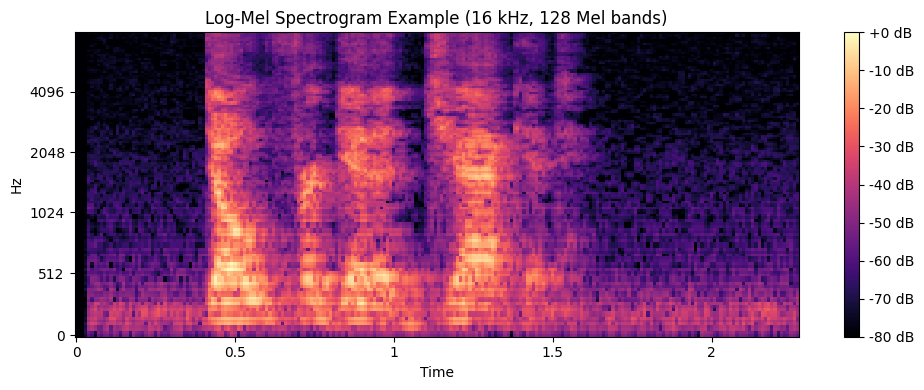

In [2]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

example_path = Path(r"C:\Code\Python\data\CREMA-D\AudioWAV\1001_DFA_ANG_XX.wav")


print(f"Using example file: {example_path}")


TARGET_SR = 16000  # 16 kHz

y, sr = librosa.load(example_path, sr=TARGET_SR, mono=True)
print(f"Loaded audio: {len(y)/sr:.2f} seconds at {sr} Hz")

n_fft = int(0.025 * sr)     # 25 ms window -> 400 at 16k
hop_length = int(0.010 * sr)  # 10 ms hop -> 160 at 16k
n_mels = 128
fmin = 0.0
fmax = 8000.0

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    fmin=fmin,
    fmax=fmax,
    power=2.0,
)

S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
    fmin=fmin,
    fmax=fmax,
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram Example (16 kHz, 128 Mel bands)")
plt.tight_layout()
plt.show()
